## Step 1: Frame the problem

**Target:** whether a person struggles to live on their household income (yes/no).

**Positive class (1):** the person finds it "difficult" or "very difficult" to live on their present income.

**User and decision:** the debt-support team of a Dutch municipality. They decide who receives a letter with an offer of help, before debts build up.

**Worst mistake:** a false negative, meaning someone who struggles but gets no letter. The system exists to help people, and someone who is missed can fall deeper into debt. A false positive (a letter someone doesn't need) costs time and money, but much less.

**Main metric: F2.** F2 weighs recall more heavily than precision, but still counts precision. We do not use recall alone, because a model that sends everyone a letter would get a perfect recall while wasting a lot of money and time.

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv("data/ess_nl_rounds4-11.csv")
df.shape

(13890, 26)

## Step 2: Explore the data

**Size:** 13,890 rows and 26 columns. Each row is one interviewed person.

In [2]:
# Target: which answers occur?
df["hincfel"].value_counts().sort_index()

hincfel
1    7458
2    4875
3    1067
4     340
7      54
8      96
Name: count, dtype: int64

**Target:** `hincfel`. Answer 3 or 4 ("difficult" or "very difficult" to live on present income) becomes 1, and answer 1 or 2 becomes 0.
- We removed 150 rows with code 7 or 8 ("refusal" or "don't know"), because we don't know whether these people struggle.
- 13,740 rows remain, of which 1,407 (10%) struggle. The data is imbalanced: a model that always says "no" is already 90% accurate.

In [3]:
# Remove refusal/don't know (7, 8) and create the target
df = df[df["hincfel"].isin([1, 2, 3, 4])]
df["struggling"] = df["hincfel"].isin([3, 4]).astype(int)
df["struggling"].value_counts()

struggling
0    12333
1     1407
Name: count, dtype: int64

**Columns we do not use as input:**
- The 13 survey-administration columns (IDs, dates, weights), because they say nothing about the person.
- `hincfel`, because the target is made from it. Using it would be leakage.
- `hinctnta` (income), because the municipality does not know residents' income.
- `gndr` and `brncntr`, so that the model does not select people by sex or origin. We keep them aside to check in step 8 whether the model is fair. People born outside NL struggle almost 3 times as often (26% vs 9%).

In [4]:
# Share struggling per group: born in NL (1) or not (2)
df.groupby("brncntr")["struggling"].mean()

brncntr
1    0.086563
2    0.260592
7    0.000000
Name: struggling, dtype: float64

**Missing values in disguise:** codes such as 7/8/9, 77/88/99 and 777/888/999 mean "refusal", "don't know" or "no answer". We replace them with `NaN`, column by column. The rows stay in, and the Pipeline imputes the gaps later.

In [5]:
# Replace disguised missing values with NaN
missing_codes = {
    "agea": [999],
    "hhmmb": [77, 88, 99],
    "domicil": [7, 8, 9],
    "eisced": [77, 88, 99],
    "hincsrca": [77, 88, 99],
    "mnactic": [66, 77, 88, 99],
    "uemp3m": [7, 8, 9],
    "wkhtot": [777, 888, 999],
}
for col, codes in missing_codes.items():
    df[col] = df[col].replace(codes, np.nan)

df.isna().sum()

name             0
essround         0
edition          0
proddate         0
idno             0
cntry            0
dweight          0
pspwght          0
pweight          0
anweight         0
prob          8962
stratum       8962
psu           8962
brncntr          0
hhmmb            9
gndr             0
agea            21
chldhm        4778
domicil          7
eisced          10
hincfel          0
hincsrca        83
hinctnta         0
mnactic         54
uemp3m          30
wkhtot         295
struggling       0
dtype: int64

`chldhm` (children at home) was not asked in 2018–2023, so more than a third of it is empty. We drop this column.

In [6]:
# chldhm: share missing per survey round
df.groupby("essround")["chldhm"].apply(lambda x: x.isna().mean())

essround
4     0.0
5     0.0
6     0.0
7     0.0
8     0.0
9     1.0
10    1.0
11    1.0
Name: chldhm, dtype: float64

**Impossible values:** working hours 666 means "not applicable" (no job), so we replace it with 0. More than 100 hours per week is not realistic, so we set those 8 values to `NaN`.

In [7]:
# Working hours: 666 = no job, so 0 hours; more than 100 hours is impossible
df["wkhtot"] = df["wkhtot"].replace(666, 0)
df.loc[df["wkhtot"] > 100, "wkhtot"] = np.nan
df["wkhtot"].describe()

count    13437.000000
mean        33.397038
std         15.915051
min          0.000000
25%         24.000000
50%         36.000000
75%         40.000000
max        100.000000
Name: wkhtot, dtype: float64

**Duplicates:** 0 exact duplicate rows. These cleaning steps learn nothing from the data. They are fixed rules from the codebook, which is why they can be done before the split.

In [8]:
# Exact duplicate rows
df.duplicated().sum()

np.int64(0)

## Step 3: Split first
We set aside 20% of the data as a test set before any preprocessing or tuning. We use `stratify=y` so that train and test both have 10% struggling people, and `random_state=42` so the split is the same every run. The test set is used exactly once, at the very end.

In [9]:
from sklearn.model_selection import train_test_split

features = ["agea", "hhmmb", "domicil", "eisced",
            "hincsrca", "mnactic", "uemp3m", "wkhtot"]

X = df[features]
y = df["struggling"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(10992, 8) (2748, 8)
0.10243813682678311 0.10225618631732168


## Step 4: Preprocessing inside a Pipeline
All preprocessing happens inside a scikit-learn `Pipeline` / `ColumnTransformer`, so it is fitted on the training data only and nothing leaks from the test set.

- **Numeric columns** (`agea`, `hhmmb`, `wkhtot`): missing values are filled with the median, then scaled with `StandardScaler`. Scaling is needed for KNN and logistic regression: KNN measures distances between people, and without scaling a column with large numbers (like age, 15–90) would dominate columns with small numbers (like 1–2). Logistic regression also trains more reliably when all columns are on the same scale.
- **Categorical columns** (`domicil`, `eisced`, `hincsrca`, `mnactic`, `uemp3m`): missing values are filled with the most frequent answer, then one-hot encoded. These codes are categories, not amounts: "retired" (6) is not twice "unemployed" (3).

**Everything we dropped:** 150 rows with an unknown target; the 13 survey-administration columns; `hincfel` (leakage); `hinctnta` (income unknown to the municipality); `chldhm` (not asked in 2018–2023); `gndr` and `brncntr` as inputs (kept for the fairness check).

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Real numbers
num_cols = ["agea", "hhmmb", "wkhtot"]
# Kinds of things (like shirt numbers)
cat_cols = ["domicil", "eisced", "hincsrca", "mnactic", "uemp3m"]

num_steps = Pipeline([
    ("impute", SimpleImputer(strategy="median")),   # piece 1: fill gaps with the median
    ("scale", StandardScaler()),                    # piece 2: same scale for every column
])

cat_steps = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),  # piece 1: fill gaps with the most common answer
    ("onehot", OneHotEncoder(handle_unknown="ignore")),   # piece 3: yes/no columns
])

preprocess = ColumnTransformer([
    ("num", num_steps, num_cols),
    ("cat", cat_steps, cat_cols),
])

## Step 5: Baseline
A `DummyClassifier` that always predicts the most common class ("not struggling"). We evaluate it with 5-fold stratified cross-validation on the training set, using F2. These same folds (`cv`) and this same metric (`f2`) are used for all models.

Result: F2 = 0.00 in every fold. The baseline never predicts "struggling", so it finds nobody (recall 0), even though its accuracy would be about 90%. This shows why accuracy is misleading here. Every model must beat F2 = 0.00.

In [11]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import make_scorer, fbeta_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Our main metric: F2
f2 = make_scorer(fbeta_score, beta=2, zero_division=0)

# The same 5 folds for every model
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline = Pipeline([
    ("prep", preprocess),
    ("model", DummyClassifier(strategy="most_frequent")),
])

scores = cross_val_score(baseline, X_train, y_train, cv=cv, scoring=f2)
print(scores)
print("F2 mean:", scores.mean(), "spread:", scores.std())

[0. 0. 0. 0. 0.]
F2 mean: 0.0 spread: 0.0


## Step 6: Tune with cross-validation
All three models are tuned on the training set only, with the same 5 folds (`cv`), the same metric (F2) and the same threshold (10%), using `GridSearchCV`.

Best k: {'estimator__model__n_neighbors': 301} F2: 0.492


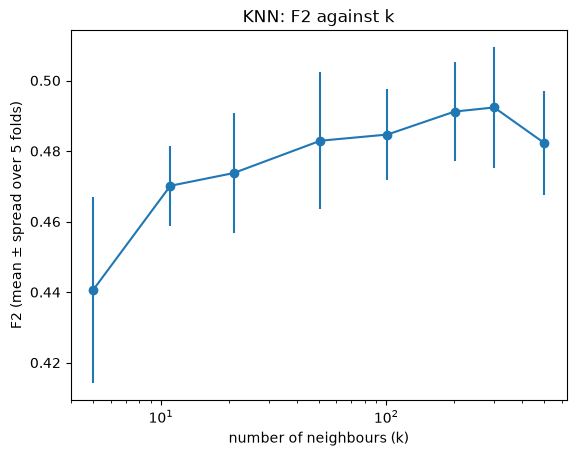

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import FixedThresholdClassifier
import matplotlib.pyplot as plt

# Same threshold for all models: "yes" if the chance is above average (10%)
THRESHOLD = 0.10

knn = FixedThresholdClassifier(
    Pipeline([
        ("prep", preprocess),
        ("model", KNeighborsClassifier()),
    ]),
    threshold=THRESHOLD,
    response_method="predict_proba",
)

knn_grid = GridSearchCV(
    knn,
    {"estimator__model__n_neighbors": [5, 11, 21, 51, 101, 201, 301, 501]},
    cv=cv, scoring=f2,
)
knn_grid.fit(X_train, y_train)

knn_results = pd.DataFrame(knn_grid.cv_results_)
print("Best k:", knn_grid.best_params_, "F2:", round(knn_grid.best_score_, 3))

# Plot: score against k
plt.errorbar(knn_results["param_estimator__model__n_neighbors"],
             knn_results["mean_test_score"],
             yerr=knn_results["std_test_score"], marker="o")
plt.xscale("log")
plt.xlabel("number of neighbours (k)")
plt.ylabel("F2 (mean ± spread over 5 folds)")
plt.title("KNN: F2 against k")
plt.show()

**KNN:** best k = 301 (CV F2 ≈ 0.49). With few neighbours the score is low and unstable; it rises up to k = 301 and drops again at 501. From k ≈ 50 onward the error bars overlap, so the differences there are small. We use a fixed threshold of 10% for all models ("yes" if the predicted chance is above the average share of 10%), because with the default 50% almost nobody is predicted as struggling.

In [13]:
from sklearn.linear_model import LogisticRegression

logreg = FixedThresholdClassifier(
    Pipeline([
        ("prep", preprocess),
        ("model", LogisticRegression(max_iter=1000)),
    ]),
    threshold=THRESHOLD,
    response_method="predict_proba",
)

logreg_grid = GridSearchCV(
    logreg,
    {"estimator__model__C": [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=cv, scoring=f2,
)
logreg_grid.fit(X_train, y_train)

logreg_results = pd.DataFrame(logreg_grid.cv_results_)
print("Best C:", logreg_grid.best_params_, "F2:", round(logreg_grid.best_score_, 3))
logreg_results[["param_estimator__model__C", "mean_test_score", "std_test_score"]]

Best C: {'estimator__model__C': 10} F2: 0.51


,param_estimator__model__C,mean_test_score,std_test_score
0,0.001,0.464435,0.018788
1,0.010,0.493269,0.015528
2,0.100,0.505060,0.012985
3,1.000,0.507988,0.013442
4,10.000,0.510136,0.013352
5,100.000,0.509394,0.012195


**Logistic regression:** best C = 10 (CV F2 ≈ 0.51). From C = 0.1 upward the scores are almost equal (0.505–0.510), and the differences are much smaller than the spread over the folds (±0.013). Only a very small C (0.001), which forces the model to be very simple, scores clearly lower.

In [14]:
from sklearn.tree import DecisionTreeClassifier

tree = FixedThresholdClassifier(
    Pipeline([
        ("prep", preprocess),
        ("model", DecisionTreeClassifier(random_state=42)),
    ]),
    threshold=THRESHOLD,
    response_method="predict_proba",
)

tree_grid = GridSearchCV(
    tree,
    {"estimator__model__max_depth": [2, 3, 4, 5, 6, 8, 10, None]},
    cv=cv, scoring=f2,
)
tree_grid.fit(X_train, y_train)

tree_results = pd.DataFrame(tree_grid.cv_results_)
print("Best:", tree_grid.best_params_, "F2:", round(tree_grid.best_score_, 3))
tree_results[["param_estimator__model__max_depth", "mean_test_score", "std_test_score"]]

Best: {'estimator__model__max_depth': 6} F2: 0.465


,param_estimator__model__max_depth,mean_test_score,std_test_score
0,2,0.404376,0.017327
1,3,0.451136,0.006780
2,4,0.447522,0.010200
3,5,0.457372,0.017630
4,6,0.465441,0.017293
5,8,0.427160,0.016451
6,10,0.389819,0.018585
7,None,0.292025,0.029639


**Decision tree:** best `max_depth` = 6 (CV F2 ≈ 0.47). A shallow tree (depth 2) is too simple and underfits. Without a depth limit (`None`) the score drops to 0.29: the tree memorises the training data and fails on new data (overfitting).

## Step 7: Evaluate once on the test set
Each tuned model is evaluated exactly once on the test set. We show the confusion matrices and put the train, cross-validation and test scores side by side.

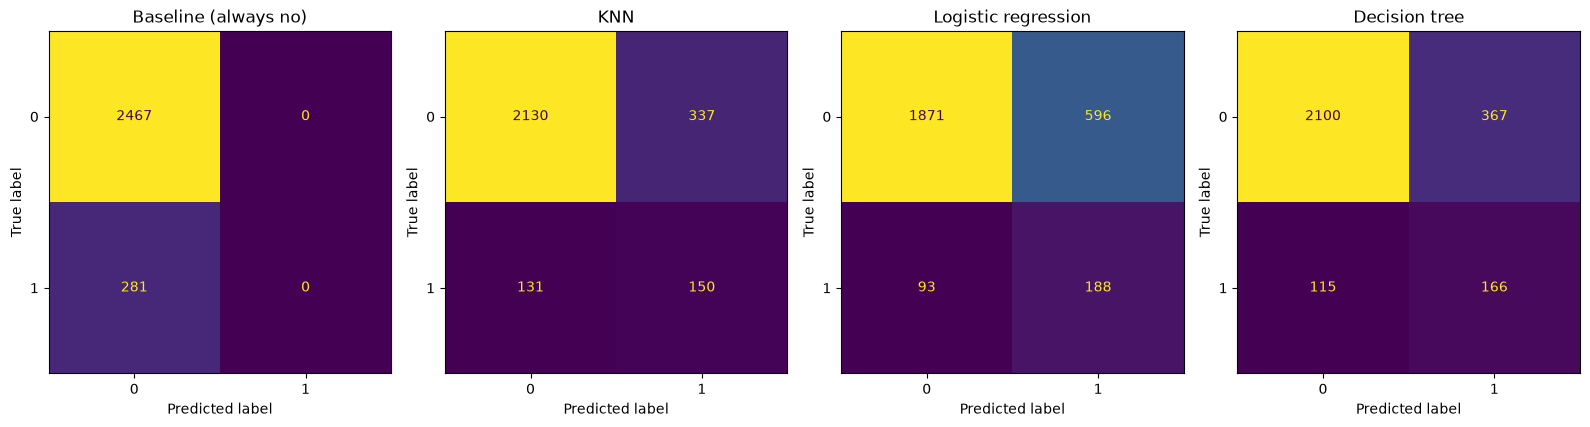

,model,train F2,CV F2 (mean ± spread),test F2,test precision,test recall,test F1
0,Baseline (always no),0.000,0.000 ± 0.000,0.000,0.000,0.000,0.000
1,KNN,0.502,0.492 ± 0.017,0.466,0.308,0.534,0.391
2,Logistic regression,0.518,0.510 ± 0.013,0.493,0.240,0.669,0.353
3,Decision tree,0.514,0.465 ± 0.017,0.501,0.311,0.591,0.408


In [15]:
from sklearn.metrics import precision_score, recall_score, ConfusionMatrixDisplay

baseline.fit(X_train, y_train)

def cv_score(grid):
    i = grid.best_index_
    return f'{grid.cv_results_["mean_test_score"][i]:.3f} ± {grid.cv_results_["std_test_score"][i]:.3f}'

models = {
    "Baseline (always no)": (baseline, f"{scores.mean():.3f} ± {scores.std():.3f}"),
    "KNN": (knn_grid.best_estimator_, cv_score(knn_grid)),
    "Logistic regression": (logreg_grid.best_estimator_, cv_score(logreg_grid)),
    "Decision tree": (tree_grid.best_estimator_, cv_score(tree_grid)),
}

rows = []
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, (model, cv_text)) in zip(axes, models.items()):
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    rows.append({
        "model": name,
        "train F2": fbeta_score(y_train, pred_train, beta=2),
        "CV F2 (mean ± spread)": cv_text,
        "test F2": fbeta_score(y_test, pred_test, beta=2),
        "test precision": precision_score(y_test, pred_test, zero_division=0),
        "test recall": recall_score(y_test, pred_test),
        "test F1": fbeta_score(y_test, pred_test, beta=1),
    })
    ConfusionMatrixDisplay.from_predictions(y_test, pred_test, ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

comparison = pd.DataFrame(rows).round(3)
comparison

**Comparison:** all three models clearly beat the baseline (F2 0.00). Train, CV and test scores are close together for KNN (0.50 / 0.49 / 0.47) and logistic regression (0.52 / 0.51 / 0.49), so they do not overfit. The decision tree scores higher on the test set (0.50) than in cross-validation (0.47); with a spread of ±0.017 this is probably luck with this particular test set, not a better model. The test F2 scores (0.47–0.50) are so close that the differences are about as large as the spread over the folds.

## Step 8: Look at the errors
We check the logistic regression model per group on the test set: sex and country of birth (not used as input, kept aside for this check) and main activity.

In [16]:
best = logreg_grid.best_estimator_

# The test rows, with all original columns (also gndr and brncntr)
test = df.loc[X_test.index].copy()
test["predicted"] = best.predict(X_test)

def group_report(col, labels):
    rows = []
    for code, label in labels.items():
        g = test[test[col] == code]
        rows.append({
            "group": label,
            "people": len(g),
            "struggling": g["struggling"].sum(),
            "share struggling": g["struggling"].mean(),
            "share getting a letter": g["predicted"].mean(),
            "recall": recall_score(g["struggling"], g["predicted"]),
            "precision": precision_score(g["struggling"], g["predicted"], zero_division=0),
        })
    return pd.DataFrame(rows).round(2)

display(group_report("gndr", {1: "men", 2: "women"}))
display(group_report("brncntr", {1: "born in NL", 2: "born outside NL"}))
display(group_report("mnactic", {1: "paid work", 3: "unemployed, looking",
                                 5: "sick/disabled", 6: "retired", 8: "housework"}))

,group,people,struggling,share struggling,share getting a letter,recall,precision
0,men,1292,107,0.08,0.24,0.64,0.22
1,women,1456,174,0.12,0.33,0.68,0.25


,group,people,struggling,share struggling,share getting a letter,recall,precision
0,born in NL,2489,215,0.09,0.27,0.64,0.20
1,born outside NL,259,66,0.25,0.43,0.77,0.46


,group,people,struggling,share struggling,share getting a letter,recall,precision
0,paid work,1485,102,0.07,0.17,0.46,0.19
1,"unemployed, looking",61,23,0.38,0.92,1.00,0.41
2,sick/disabled,136,51,0.38,0.93,0.98,0.39
3,retired,519,33,0.06,0.15,0.27,0.12
4,housework,291,41,0.14,0.51,0.78,0.22


**Findings (logistic regression, test set):**
- Men and women are treated about equally (recall 0.64 vs 0.68).
- People born outside NL get a letter more often (43% vs 27%), but they also struggle almost 3 times as often (25% vs 9%). The model even finds them better (recall 0.77 vs 0.64), so they are not flagged without reason. Country of birth is not an input, but it may partly hide in other columns, such as source of income.
- Retired people who struggle are found worst (recall 0.27), followed by working people (0.46). The model mainly learns "unemployed or sick = struggling"; people with a job or pension who still struggle (e.g. because of rent or debts) are mostly missed. Their problems are not in the data.
- Some groups are small (e.g. only 33 struggling retired people in the test set), so these numbers are uncertain.

## Step 9: Recommendation
We recommend **logistic regression** to the municipality's debt-support team.
- It misses the fewest people who struggle (93 of 281 in the test set; recall 0.67). Missing someone is the worst mistake for our user.
- It has the best and most stable cross-validation score (F2 0.51 ± 0.013), and train, CV and test scores are close, so it does not overfit.
- The decision tree has a slightly higher test F2 (0.50 vs 0.49), but the difference is smaller than the spread over the folds, its CV score is lower (0.47), and it misses 22 more people.
- Logistic regression is explainable: each column has a weight, so the municipality can tell a resident why they received a letter.

**But only as a voluntary offer of help**, next to existing signals such as payment arrears. About 3 in 4 letters go to people who manage fine (precision 0.24), and retired and working people who struggle are often missed. The model must never be used to cut benefits or to check people.

## Step 10: Use it
A new, made-up resident: 45 years old, household of 3, lives in a big city, lower secondary education, main income from social benefits, unemployed and looking for work, has been unemployed for more than 3 months before, works 0 hours.

In [17]:
new_person = pd.DataFrame([{
    "agea": 45,       # age
    "hhmmb": 3,       # people in household
    "domicil": 1,     # big city
    "eisced": 2,      # lower secondary education
    "hincsrca": 6,    # main income: social benefits
    "mnactic": 3,     # unemployed, looking for a job
    "uemp3m": 1,      # ever unemployed > 3 months: yes
    "wkhtot": 0,      # working hours per week
}])

prediction = best.predict(new_person)[0]
probability = best.predict_proba(new_person)[0, 1]

print("Prediction:", "struggling → send a letter" if prediction == 1 else "not struggling → no letter")
print(f"Chance of struggling: {probability:.0%} (threshold {THRESHOLD:.0%})")

Prediction: struggling → send a letter
Chance of struggling: 83% (threshold 10%)
